# Import Libraries

In [24]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
# Weather data library
from meteostat import Stations, Daily
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Connect SageMaker to S3

In [25]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

forest/combined_forest_data.csv
processed/
raw/
raw/fire/
raw/fire/California_Historic_Fire_Perimeters.csv
raw/forest/
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/weather/
weather/california_weather_data.csv


The datasets used in this project were originally downloaded from public government data sources- the U.S. Forest Service (FIA), CAL FIRE wildfire records and NOAA weather data accessed through the Meteostat. After downloading, the files were manually uploaded to an Amazon S3 bucket. The datasets are accessed from Amazon S3 using SageMaker Studio notebooks for exploration and further processing.

# Load FIA(forest vegetation data) from S3

The FIA forest vegetation dataset consists of three tables: subplot information, tree characteristics, and biomass measurements. These files are stored in Amazon S3 and loaded into the SageMaker notebook for further analysis. 

In [26]:
#file path for FIA forest datasets inside S3 bucket
subplot_path = "s3://vegetation-risk-ml/raw/forest/CA_SUBPLOT.csv"
tree_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE.csv"
biomass_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE_REGIONAL_BIOMASS.csv"

In [27]:
# Load the CSV file from S3 into a pandas DataFrame
subplot = pd.read_csv(subplot_path, low_memory=False)
subplot.head(3)

,CN,PLT_CN,PREV_SBP_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,SUBP_STATUS_CD,...,GROUND_TRAN_PTS_OTHER_RMRS,GROUND_TRAN_PTS_PEIS_RMRS,GROUND_TRAN_PTS_ROAD_RMRS,GROUND_TRAN_PTS_ROCK_RMRS,GROUND_TRAN_PTS_TRIS_RMRS,GROUND_TRAN_PTS_VEG_RMRS,GROUND_TRAN_PTS_WATER_RMRS,GROUND_TRAN_PTS_WOOD_RMRS,PREV_STATUSCD_RMRS,ROOTSEVCD_RMRS
0,59015,11839,NaN,1994,6,1,15,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59042,11839,NaN,1994,6,1,15,1,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59068,11839,NaN,1994,6,1,15,1,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
trees = pd.read_csv(tree_path, low_memory=False)
trees.head(3)

,CN,PLT_CN,PREV_TRE_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,TREE,...,DRYBIO_STUMP_BARK,DRYBIO_BOLE_BARK,DRYBIO_BRANCH,DRYBIO_FOLIAGE,DRYBIO_SAWLOG_BARK,PREV_ACTUALHT_FLD,PREV_HT_FLD,UTILCLCD,SPCD_ID_CD,ABNORMAL_TERMINATION
0,675267,11839,NaN,1994,6,1,15,1,1,675267,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,675268,11839,NaN,1994,6,1,15,1,1,675268,...,17.718832,469.383932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,675269,11839,NaN,1994,6,1,15,1,1,675269,...,10.354492,143.559569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
biomass = pd.read_csv(biomass_path, low_memory=False)
biomass.head(3)

,TRE_CN,STATECD,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM,CREATED_BY,CREATED_DATE,CREATED_IN_INSTANCE,MODIFIED_BY,MODIFIED_DATE,MODIFIED_IN_INSTANCE,REGIONAL_DRYBIOSL
0,44784050020004,6,181.351518,94.186487,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,NaN
1,44784051020004,6,244.463259,167.318417,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,152.313767
2,44784052020004,6,356.127994,204.940133,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,187.352578


In [30]:
#basic data structure
subplot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178917 entries, 0 to 178916
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CN                             178917 non-null  int64  
 1   PLT_CN                         178917 non-null  int64  
 2   PREV_SBP_CN                    3384 non-null    float64
 3   INVYR                          178917 non-null  int64  
 4   STATECD                        178917 non-null  int64  
 5   UNITCD                         178917 non-null  int64  
 6   COUNTYCD                       178917 non-null  int64  
 7   PLOT                           178917 non-null  int64  
 8   SUBP                           178917 non-null  int64  
 9   SUBP_STATUS_CD                 178917 non-null  int64  
 10  POINT_NONSAMPLE_REASN_CD       9005 non-null    float64
 11  MICRCOND                       155600 non-null  float64
 12  SUBPCOND                      

In [31]:
#basic data structure
trees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446320 entries, 0 to 446319
Columns: 198 entries, CN to ABNORMAL_TERMINATION
dtypes: float64(181), int64(13), object(4)
memory usage: 674.2+ MB


In [32]:
#basic data structure
biomass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390955 entries, 0 to 390954
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TRE_CN                390955 non-null  int64  
 1   STATECD               390955 non-null  int64  
 2   REGIONAL_DRYBIOT      316455 non-null  float64
 3   REGIONAL_DRYBIOM      329615 non-null  float64
 4   CREATED_BY            390955 non-null  object 
 5   CREATED_DATE          390955 non-null  object 
 6   CREATED_IN_INSTANCE   390955 non-null  int64  
 7   MODIFIED_BY           390955 non-null  object 
 8   MODIFIED_DATE         390955 non-null  object 
 9   MODIFIED_IN_INSTANCE  390955 non-null  int64  
 10  REGIONAL_DRYBIOSL     137020 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 32.8+ MB


In [33]:
#Merge trees and subplot.To save memory, we will choose needed columns only
combined_forest = trees[["CN", "PLT_CN", "DIA", "HT", "SPCD", "STATUSCD"]].merge(subplot[["PLT_CN", "SLOPE", "ASPECT"]],
    on="PLT_CN",how="left")

#Merge the resulting dataframe with biomass dataframe on tree identifier.Again, select needed columns to save memory
combined_forest = combined_forest.merge(biomass[["TRE_CN", "REGIONAL_DRYBIOT", "REGIONAL_DRYBIOM"]],left_on="CN",right_on="TRE_CN",how="left")

#Check the resulting dataframe
print("Merged forest dataset shape:", combined_forest.shape)
combined_forest.head()

Merged forest dataset shape: (1825026, 11)


,CN,PLT_CN,DIA,HT,SPCD,STATUSCD,SLOPE,ASPECT,TRE_CN,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM
0,675267,11839,3.9,43.0,631.0,1,50.0,225.0,675267.0,NaN,0.0
1,675267,11839,3.9,43.0,631.0,1,50.0,225.0,675267.0,NaN,0.0
2,675267,11839,3.9,43.0,631.0,1,60.0,225.0,675267.0,NaN,0.0
3,675267,11839,3.9,43.0,631.0,1,50.0,225.0,675267.0,NaN,0.0
4,675267,11839,3.9,43.0,631.0,1,40.0,180.0,675267.0,NaN,0.0


The three FIA datasets are merged to create a unified forest vegetation dataset. The merge connects tree measurements with subplot environmental characteristics and biomass estimates.

In [34]:
#Save this merged dataframe to S3 for future use
combined_forest.to_csv("s3://vegetation-risk-ml/forest/combined_forest_data.csv", index=False)

# Load CALFIRE dataset from S3

The CAL FIRE dataset contains wildfire perimeter records for California, originaly downloaded from public website and uploaded manully into S3 in raw/fire folder.This dataset provides information on fire location, cause, start date, and burned area.

In [35]:
# Path to wildfire dataset stored in S3
fire_path = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_Perimeters.csv"

# Load wildfire dataset
fire = pd.read_csv(fire_path)

# Display dataset shape and rows
print("Fire dataset shape:", fire.shape)
fire.head(3)

Fire dataset shape: (22810, 21)


,OBJECTID,Year,State,Agency,Unit ID,Fire Name,Local Incident Number,Alarm Date,Containment Date,Cause,...,Management Objective,GIS Calculated Acres,Comments,Complex Name,IRWIN ID,Fire Number (historical use),Complex ID,DECADES,Shape__Area,Shape__Length
0,1,2025.0,CA,CDF,LDF,PALISADES,00000738,1/7/2025 8:00:00 AM,1/31/2025 8:00:00 AM,14,...,1.0,23448.88,NaN,NaN,{A7EA5D21-F882-44B8-BF64-44AB11059DC1},NaN,NaN,2020-January 2025,1.386518e+08,140231.608232
1,2,2025.0,CA,CDF,LAC,EATON,00009087,1/8/2025 8:00:00 AM,1/31/2025 8:00:00 AM,14,...,1.0,14056.26,NaN,NaN,{72660ADC-B5EF-4D96-A33F-B4EA3740A4E3},NaN,NaN,2020-January 2025,8.336393e+07,104933.207224
2,3,2025.0,CA,CDF,ANF,HUGHES,00250270,1/22/2025 8:00:00 AM,1/28/2025 8:00:00 AM,14,...,1.0,10396.80,NaN,NaN,{994072D2-E154-434A-BB95-6F6C94C40829},NaN,NaN,2020-January 2025,6.216064e+07,96698.599858


In [36]:
#Basic structure of fire dataset
print(fire.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22810 entries, 0 to 22809
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   OBJECTID                      22810 non-null  int64  
 1   Year                          22733 non-null  float64
 2   State                         22810 non-null  object 
 3   Agency                        22761 non-null  object 
 4   Unit ID                       22749 non-null  object 
 5   Fire Name                     22638 non-null  object 
 6   Local Incident Number         21839 non-null  object 
 7   Alarm Date                    17414 non-null  object 
 8   Containment Date              10180 non-null  object 
 9   Cause                         22810 non-null  int64  
 10  Collection Method             10708 non-null  float64
 11  Management Objective          22539 non-null  float64
 12  GIS Calculated Acres          22810 non-null  float64
 13  C

In [37]:
#missing values in fire dataset
print(fire.isnull().sum())

OBJECTID                            0
Year                               77
State                               0
Agency                             49
Unit ID                            61
Fire Name                         172
Local Incident Number             971
Alarm Date                       5396
Containment Date                12630
Cause                               0
Collection Method               12102
Management Objective              271
GIS Calculated Acres                0
Comments                        19975
Complex Name                    22210
IRWIN ID                        19668
Fire Number (historical use)     5610
Complex ID                      22244
DECADES                            77
Shape__Area                         0
Shape__Length                       0
dtype: int64


In [38]:
#duplicated values in fire dataset
print(fire.duplicated().sum())

0


# Load Weather Data Using Meteostat

Weather stations across California are retrieved using the Meteostat API. These stations provide historical weather measurements such as temperature and precipitation.

In [39]:
# Retrieve weather stations located in California
stations = Stations()

stations = stations.region('US', 'CA')
stations = stations.fetch(100)

print(stations.head())

# download weather data
start = datetime(2015,1,1)
end = datetime(2026,1,1)

weather_data = []

for station_id in stations.index[:50]:
    
    data = Daily(station_id, start, end)
    data = data.fetch()
    
    data['station'] = station_id
    
    weather_data.append(data)

weather = pd.concat(weather_data)

weather.reset_index(inplace=True)

weather.head()

                                     name country region    wmo  icao  \
id                                                                      
69002      Hunter Ligget / Hunter-Liggett      US     CA  69002  KHGT   
69007                   Fort Ord / Blanco      US     CA  69007  KOAR   
69014                              Irvine      US     CA  69014  KNZJ   
69015  Twentynine Palms / Sunfair Heights      US     CA  69015  KNXP   
69542                Monterey / Del Monte      US     CA  69542  KQNM   

       latitude  longitude  elevation             timezone hourly_start  \
id                                                                        
69002   35.9935  -121.2367      310.0  America/Los_Angeles   1964-07-15   
69007   36.6815  -121.7617       42.0  America/Los_Angeles   1973-01-02   
69014   33.6667  -117.7167      119.0  America/Los_Angeles   1989-01-01   
69015   34.2962  -116.1622      625.0  America/Los_Angeles   1990-01-02   
69542   36.5900  -121.8600      152.0 

,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,station
0,2020-11-05,13.5,8.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
1,2020-11-06,12.1,8.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
2,2020-11-07,9.9,6.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
3,2020-11-08,9.1,2.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
4,2020-11-09,5.5,-1.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007


In [40]:
#Summary statistics of weather data
weather.describe()

,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
count,159235,152333.000000,158959.000000,158959.000000,143040.000000,43636.000000,106811.000000,152006.000000,0.0,137446.000000,0.0
mean,2020-08-29 20:22:52.311363840,16.797217,10.503067,22.688162,1.068746,0.051082,236.228759,11.774533,NaN,1015.370383,NaN
min,2015-01-01 00:00:00,-28.700000,-39.000000,-27.800000,0.000000,0.000000,0.000000,0.000000,NaN,977.900000,NaN
25%,2017-12-02 00:00:00,12.100000,6.700000,17.200000,0.000000,0.000000,169.000000,7.600000,NaN,1012.000000,NaN
50%,2020-10-12 00:00:00,15.900000,11.000000,21.700000,0.000000,0.000000,271.000000,10.300000,NaN,1014.900000,NaN
75%,2023-06-05 00:00:00,20.800000,14.800000,27.800000,0.000000,0.000000,319.000000,14.400000,NaN,1018.500000,NaN
max,2026-01-01 00:00:00,43.700000,37.200000,61.000000,907.400000,230.000000,360.000000,125.600000,NaN,1038.500000,NaN
std,NaN,6.858638,7.028203,8.644289,5.661136,2.511425,103.917898,6.514485,NaN,4.901558,NaN


In [41]:
#missing values
print(weather.isnull().sum())

time            0
tavg         6902
tmin          276
tmax          276
prcp        16195
snow       115599
wdir        52424
wspd         7229
wpgt       159235
pres        21789
tsun       159235
station         0
dtype: int64


In [42]:
# save the weather data to S3 for future use
weather.to_csv("s3://vegetation-risk-ml/weather/california_weather_data.csv", index=False)

# DATA EXPLORATION

### What are the distributions and relationships among key weather variables (temperature, precipitation, and wind speed) across California?
    

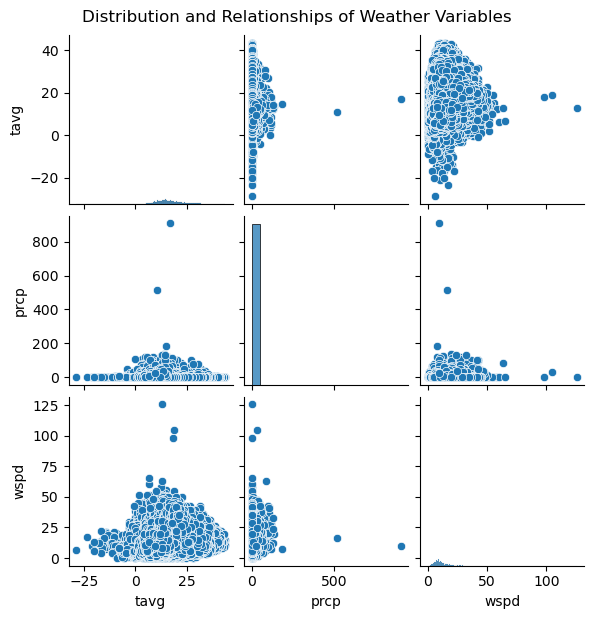

In [43]:

weather_subset = weather[["tavg","prcp","wspd"]]

sns.pairplot(weather_subset, height=2)

plt.suptitle("Distribution and Relationships of Weather Variables", y=1.02)
plt.show()

The pairplot visualization shows the distributions of temperature, precipitation, and wind speed, as well as their relationships. Understanding these climate variables is important because weather conditions influence vegetation growth, dryness, and wildfire spread.

### Is wildfire size distribution skewed toward extreme events?

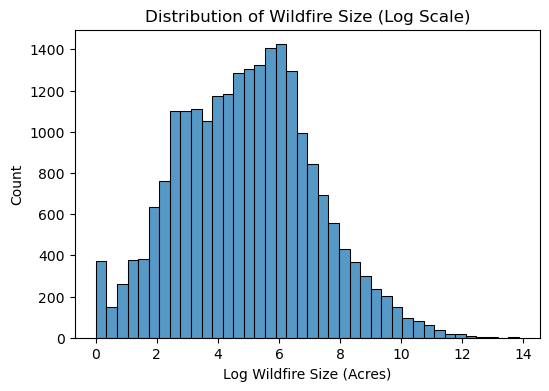

In [44]:
import numpy as np

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(fire["GIS Calculated Acres"]), bins=40)

plt.xlabel("Log Wildfire Size (Acres)")
plt.title("Distribution of Wildfire Size (Log Scale)")
plt.show()

Plot shows Wildfire data is right-skewed.A skewed wildfire size distribution indicates that while most fires are small, a few extremely large fires dominate total burned area.

### What is the distribution of vegetation biomass across forest plots?

This directly uses your forest dataset and helps understand fuel load, which is important for wildfire risk.

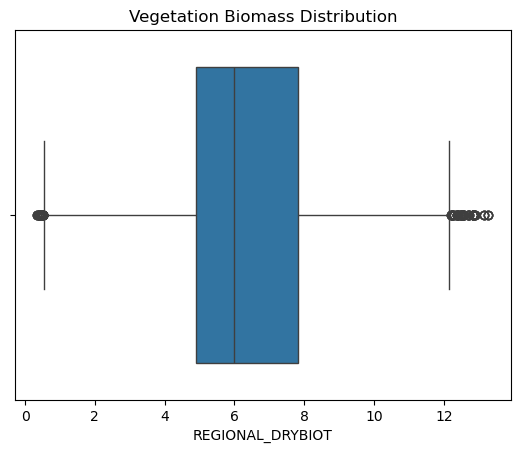

In [45]:
sns.boxplot(x=np.log1p(combined_forest["REGIONAL_DRYBIOT"]))

plt.title("Vegetation Biomass Distribution")
plt.show()

The vegetation biomass distribution is highly right-skewed, indicating that most forest plots contain relatively low to moderate biomass while a small number of plots have extremely high biomass values. These high-biomass areas may represent dense vegetation and potentially higher fuel loads that could contribute to wildfire risk.

### How has wildfire frequency and burned area changed over time in California?

Text(0.5, 1.0, 'Wildfire Frequency Over Time')

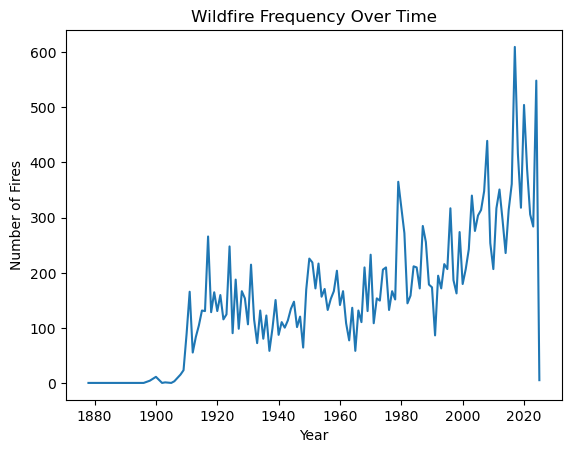

In [46]:
fires_per_year = fire.groupby("Year").size()
fires_per_year.plot()

plt.xlabel("Year")
plt.ylabel("Number of Fires")
plt.title("Wildfire Frequency Over Time")

This visualization helps identify geographic regions with higher wildfire activity, which may correspond to areas with higher vegetation fuel loads.